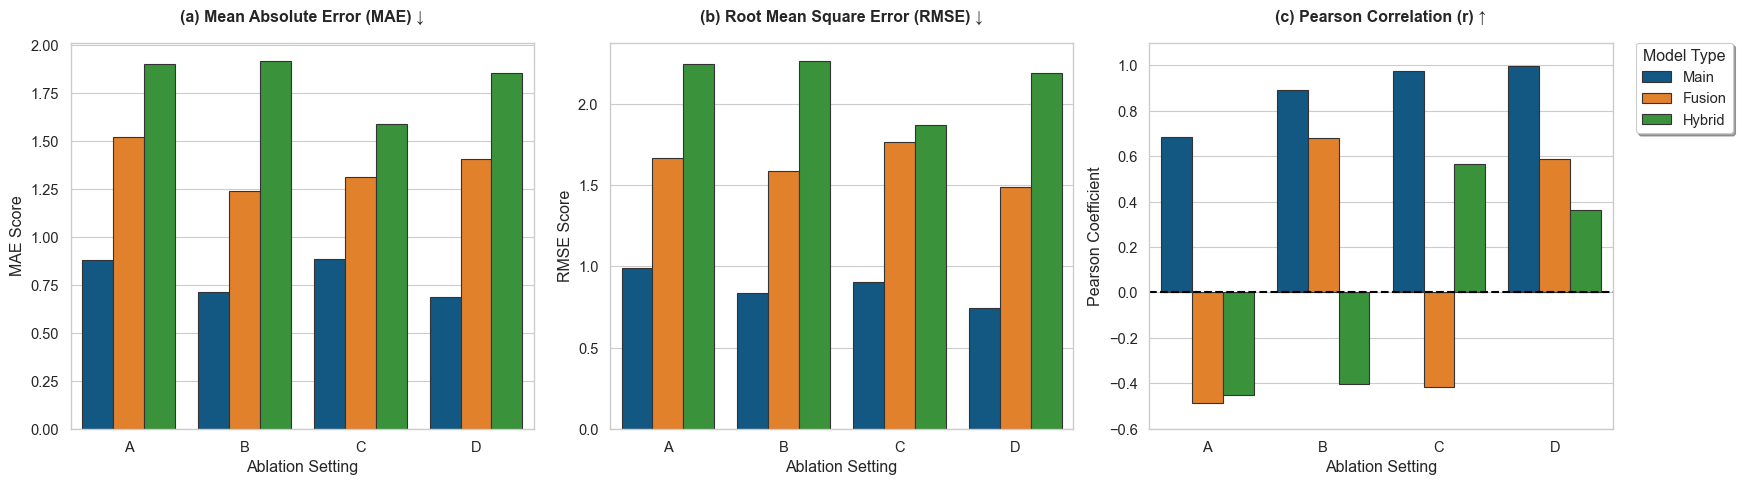

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import io

# 데이터 준비
csv_data = """Model,Ablation,MAE,RMSE,Pearson r
Main,A,0.879,0.992,0.684
Main,B,0.714,0.835,0.892
Main,C,0.883,0.905,0.976
Main,D,0.687,0.743,0.996
Fusion,A,1.520,1.667,-0.488
Fusion,B,1.237,1.586,0.679
Fusion,C,1.310,1.768,-0.416
Fusion,D,1.408,1.489,0.588
Hybrid,A,1.900,2.245,-0.452
Hybrid,B,1.917,2.266,-0.401
Hybrid,C,1.590,1.869,0.565
Hybrid,D,1.855,2.191,0.361"""

df = pd.read_csv(io.StringIO(csv_data))

# --- 시각화 스타일 설정 ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
# 논문에 어울리는 전문적인 색상 팔레트 설정 (Main: 진한 파랑, Fusion: 주황, Hybrid: 녹색)
custom_palette = ["#005b96", "#ff7f0e", "#2ca02c"]

# 그림 생성 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

# --- 1. MAE 그래프 (낮을수록 좋음) ---
sns.barplot(data=df, x="Ablation", y="MAE", hue="Model", palette=custom_palette, ax=axes[0], edgecolor=".2")
axes[0].set_title("(a) Mean Absolute Error (MAE) ↓", fontweight='bold', pad=15)
axes[0].set_ylabel("MAE Score")
axes[0].set_xlabel("Ablation Setting")
axes[0].legend_.remove() # 범례는 마지막에 하나만 표시

# --- 2. RMSE 그래프 (낮을수록 좋음) ---
sns.barplot(data=df, x="Ablation", y="RMSE", hue="Model", palette=custom_palette, ax=axes[1], edgecolor=".2")
axes[1].set_title("(b) Root Mean Square Error (RMSE) ↓", fontweight='bold', pad=15)
axes[1].set_ylabel("RMSE Score")
axes[1].set_xlabel("Ablation Setting")
axes[1].legend_.remove()

# --- 3. Pearson r 그래프 (높을수록 좋음, 핵심!) ---
sns.barplot(data=df, x="Ablation", y="Pearson r", hue="Model", palette=custom_palette, ax=axes[2], edgecolor=".2")
axes[2].set_title("(c) Pearson Correlation (r) ↑", fontweight='bold', pad=15)
axes[2].set_ylabel("Pearson Coefficient")
axes[2].set_xlabel("Ablation Setting")

# 0점 기준선 추가 (음수/양수 구분 강조)
axes[2].axhline(0, color='black', linestyle='--', linewidth=1.5)
# Y축 범위 설정 (음수 결과가 잘 보이도록)
axes[2].set_ylim(-0.6, 1.1)

# 범례 설정 (세 번째 그래프 옆에 배치)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Model Type", frameon=True, shadow=True)

# --- 전체 레이아웃 조정 ---
plt.tight_layout()
plt.subplots_adjust(right=0.9) # 범례 공간 확보

# 그래프 저장 또는 출력
# plt.savefig("ablation_results_kdd.png", dpi=300, bbox_inches='tight')
plt.show()

In [2]:
!pip install matplotlib seaborn pandas

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/7.5 MB ? eta -:--:--
   ------ --------------------------------- 1.3/7.5 MB 6.1 MB/s eta 0:00:02
   ------------- -------------------------- 2.6/7.5 MB 6.3 MB/s eta 0:00:01
   ----------------------- ---------------- 4.5/7.5 MB 7.5 MB/s eta 0:00:01
   ------------------------------ --------- 5.8/7.5 MB 7.2 MB/s eta 0:00:01
   ------------------------------------- -- 7.1/7.5 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 7.5/7.5 MB 6.7 MB/s eta 0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 8.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   -------------------- -

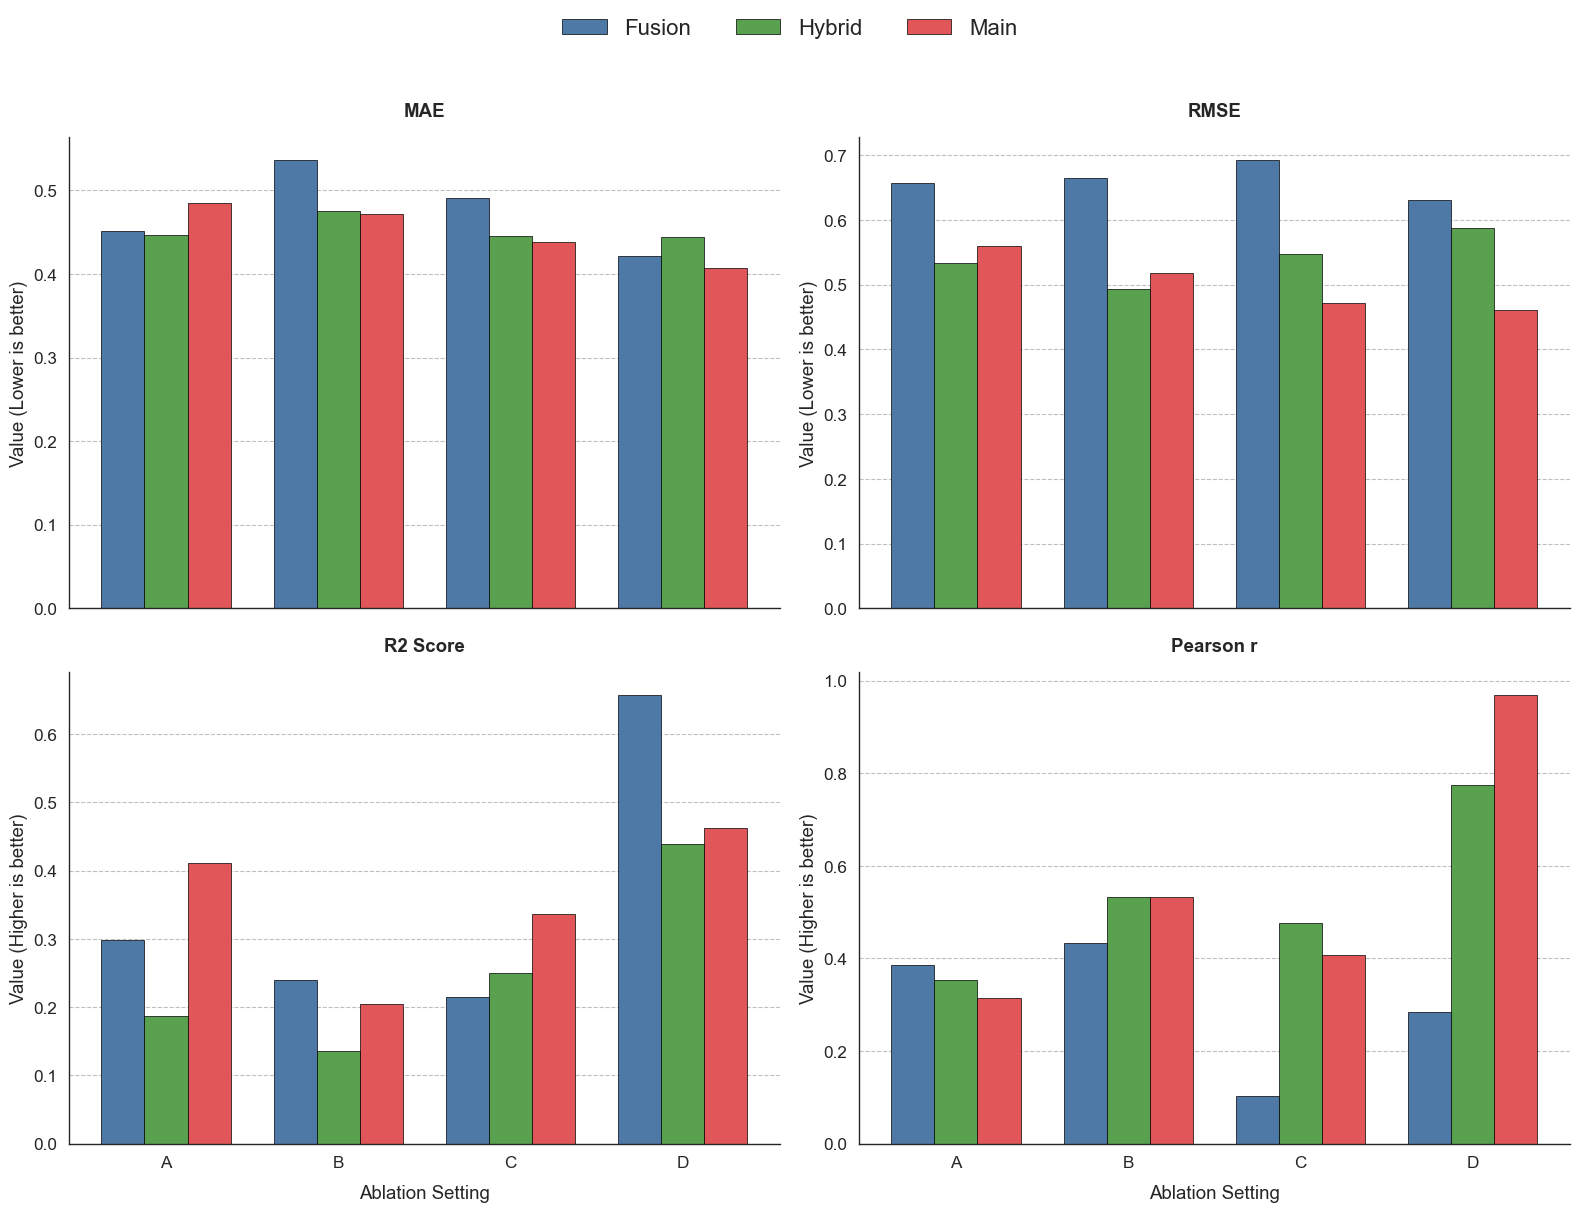

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- 1. 데이터 준비 ---
ablations = ['A', 'B', 'C', 'D']
models = ['Fusion', 'Hybrid', 'Main']

# 데이터 (입력해주신 값을 그대로 사용)
data = {
    'MAE': {
        'Fusion': [0.4519, 0.5368, 0.4910, 0.4209],
        'Hybrid': [0.4472, 0.4759, 0.4457, 0.4439],
        'Main':   [0.4853, 0.4714, 0.4379, 0.4067]
    },
    'RMSE': {
        'Fusion': [0.6570, 0.6646, 0.6932, 0.6307],
        'Hybrid': [0.5336, 0.4932, 0.5477, 0.5878],
        'Main':   [0.5601, 0.5173, 0.4722, 0.4604]
    },
    'R2 Score': {
        'Fusion': [0.2985, 0.2403, 0.2154, 0.6576],
        'Hybrid': [0.1864, 0.135, 0.2497, 0.4394],
        'Main':   [0.4118, 0.2040, 0.3371, 0.4626]
    },
    'Pearson r': {
        'Fusion': [0.3855, 0.4336, 0.1030, 0.2851],
        'Hybrid': [0.3527, 0.5334, 0.4755, 0.7754],
        'Main':   [0.3154, 0.5333, 0.4068, 0.9695]
    }
}

# --- 2. 논문 스타일 설정 ---
# seaborn을 사용하여 전반적인 스타일을 학술지 포맷에 맞춥니다.
sns.set_theme(style="white", context="paper", font_scale=1.4)
# 논문에 어울리는 차분한 색상 팔레트 정의 (파랑, 초록, 빨강 계열)
colors = ["#4E79A7", "#59A14F", "#E15759"]

# --- 3. 플롯 생성 ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
# 전체 서브플롯 간격 조정
fig.subplots_adjust(hspace=0.25, wspace=0.2)

metrics = list(data.keys())
x = np.arange(len(ablations))
width = 0.25  # 막대 너비

# 4개의 서브플롯 반복 생성
for i, ax in enumerate(axes.flat):
    metric_name = metrics[i]
    metric_data = data[metric_name]
    
    # 각 모델별 막대 그리기
    rects1 = ax.bar(x - width, metric_data['Fusion'], width, label='Fusion', color=colors[0], edgecolor='black', linewidth=0.5)
    rects2 = ax.bar(x, metric_data['Hybrid'], width, label='Hybrid', color=colors[1], edgecolor='black', linewidth=0.5)
    rects3 = ax.bar(x + width, metric_data['Main'], width, label='Main', color=colors[2], edgecolor='black', linewidth=0.5)

    # 축 및 타이틀 설정
    ax.set_title(metric_name, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(ablations)
    
    # Y축 레이블 설정 (손실 함수는 낮을수록, 상관계수는 높을수록 좋음을 표시)
    if metric_name in ['MAE', 'RMSE']:
        ax.set_ylabel("Value (Lower is better)")
    else:
        ax.set_ylabel("Value (Higher is better)")
        
    # 불필요한 테두리 제거 및 그리드 추가
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
    ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.5)
    ax.set_axisbelow(True) # 그리드가 막대 뒤로 가게 설정

# X축 레이블은 하단 플롯에만 표시
axes[1, 0].set_xlabel("Ablation Setting", labelpad=10)
axes[1, 1].set_xlabel("Ablation Setting", labelpad=10)

# 범례는 그래프 상단 중앙에 한 번만 표시
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=3, frameon=False, fontsize=16)

# --- 4. 저장 및 출력 ---
# 여백 자동 조정 (범례 공간 고려)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# 고해상도 논문용 파일 저장 예시 (주석 해제 후 사용)
# plt.savefig('ablation_study_results.pdf', format='pdf', bbox_inches='tight', dpi=300)
# plt.savefig('ablation_study_results.png', format='png', bbox_inches='tight', dpi=300)

plt.show()